<a href="https://colab.research.google.com/github/unclesam243/Project_ML/blob/main/Project_milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# Methods: Logistic Regression | Random Forest | XGBoost | MLP
# Dataset: ULB Credit Card Fraud Detection (Kaggle)
# Evaluation: 5-seed mean ± std | AUPRC primary metric
# ============================================================

# ============================================================
# STEP 0 — Install & Import Libraries
# ============================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# I'm setting seeds so results are reproducible across runs
SEEDS = [42, 123, 256, 789, 1024]



In [15]:
# ============================================================
# STEP 1 — Load & Verify Dataset
# ============================================================
# from google.colab import files
# uploaded = files.upload()  # Upload creditcard.csv when prompted

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')#, on_bad_lines='skip')

# Ensure V-columns are numeric, coercing errors to NaN
for i in range(1, 29):
    col_name = f'V{i}'
    if col_name in df.columns:
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# Verify dataset- Just printing what we have to make sure it loaded correctly
print(f"Dataset shape:   {df.shape}")
print(f"Transactions:    {df.shape[0]:,}  (expected 284,807)") # going of the description in Kaggle
print(f"Columns:         {df.shape[1]}    (expected 31)")
print(f"Fraud cases:     {df['Class'].sum()} (expected 492)")
print(f"Missing values:  {df.isnull().sum().sum()} (expected 0)")
print(f"\nColumns: {list(df.columns)}")

# Verify V1-V28 are already PCA-transformed (should be ~zero mean)
v_means = df[[f'V{i}' for i in range(1,29)]].mean()
print(f"\nV1-V28 mean (should be ~0): min={v_means.min():.4f}, max={v_means.max():.4f}")

Dataset shape:   (284807, 31)
Transactions:    284,807  (expected 284,807)
Columns:         31    (expected 31)
Fraud cases:     492 (expected 492)
Missing values:  0 (expected 0)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

V1-V28 mean (should be ~0): min=-0.0000, max=0.0000


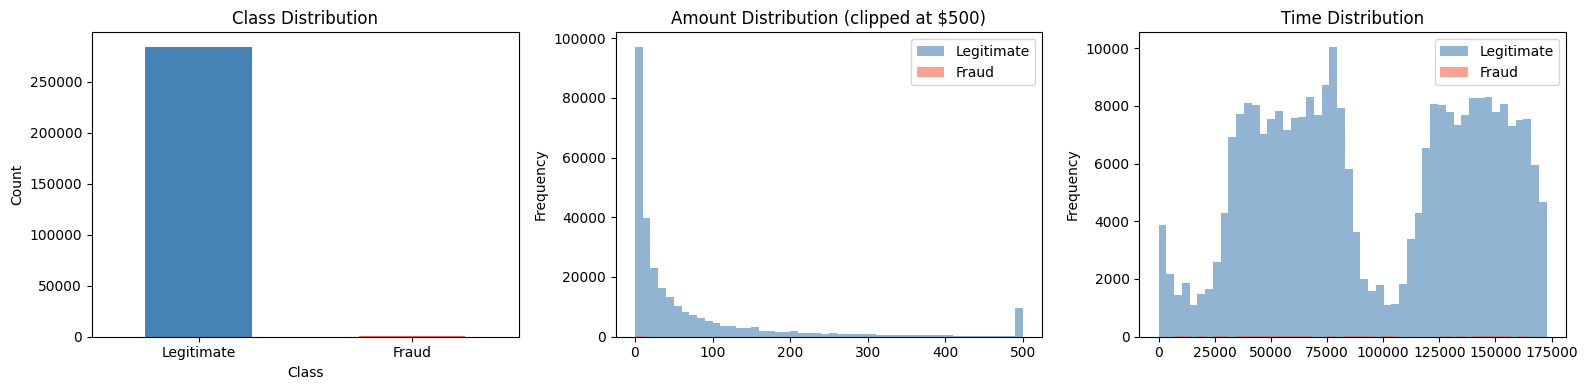

In [16]:

# ============================================================
# STEP 2 — Exploratory Data Analysis
# ============================================================

# Trying to evaluate the fraud vs legitimate transaction count
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

# This is for the histogram
df[df['Class']==0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Fraud', color='tomato')
axes[1].set_title('Amount Distribution (clipped at $500)')
axes[1].legend()
 # This is for the time distribution
df[df['Class']==0]['Time'].plot(
    kind='hist', bins=50, ax=axes[2], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Time'].plot(
    kind='hist', bins=50, ax=axes[2], alpha=0.6, label='Fraud', color='tomato')
axes[2].set_title('Time Distribution')
axes[2].legend()
# Combination layout


plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()




In [17]:
# ============================================================
# Step 3 - Preprocessing
# ============================================================
# Handle missing values (found 5 in Step 1)
df.dropna(inplace=True)

X = df.drop(columns=['Class'])
y = df['Class']

# --- Temporal split (60% train / 20% val / 20% test) ---
# I'm sorting by time first so the split is chronological
# This is important because a random split could leak fraud patterns
# that happen in the same time window across train and test
df_sorted = df.sort_values('Time').reset_index(drop=True)
n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = df_sorted.iloc[:train_end].drop(columns=['Class']).copy()
y_train = df_sorted.iloc[:train_end]['Class']
X_val   = df_sorted.iloc[train_end:val_end].drop(columns=['Class']).copy()
y_val   = df_sorted.iloc[train_end:val_end]['Class']
X_test  = df_sorted.iloc[val_end:].drop(columns=['Class']).copy()
y_test  = df_sorted.iloc[val_end:]['Class']

print(f"Train: {len(X_train):,} samples | Fraud: {y_train.sum()}")
print(f"Val:   {len(X_val):,}   samples | Fraud: {y_val.sum()}")
print(f"Test:  {len(X_test):,}  samples | Fraud: {y_test.sum()}")

#V1-V28 are already PCA transformed so we leave them alone
# RobustScaler is better here than StandardScaler because Amount
# has extreme outliers (max ~$25k) that would skew the mean/std
scaler = RobustScaler()
X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_val[['Time','Amount']]   = scaler.transform(X_val[['Time','Amount']])
X_test[['Time','Amount']]  = scaler.transform(X_test[['Time','Amount']])
# Important: we only fit on training data, then apply to val/test
# Fitting on test too would be data leakage

# --- Class weights ---
# Instead of SMOTE, we use class weighting
# This tells the model that missing a fraud is much worse than a false alarm
n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
w1 = n_legit / len(y_train)  # weight for fraud
w0 = n_fraud / len(y_train)  # weight for legit
print(f"\nFraud weight (w1): {w1:.4f}")
print(f"Legit weight (w0): {w0:.4f}")
print(f"Ratio w1/w0:       {w1/w0:.1f}x")

Train: 170,884 samples | Fraud: 360
Val:   56,961   samples | Fraud: 57
Test:  56,962  samples | Fraud: 75

Fraud weight (w1): 0.9979
Legit weight (w0): 0.0021
Ratio w1/w0:       473.7x


In [18]:

# ============================================================
# STEP 4 — Evaluation Helper
# ============================================================
def evaluate(name, y_true, y_probs, threshold=0.5):
    # Compute all metrics at a given threshold
    y_preds = (y_probs >= threshold).astype(int)
    return {
        'Model':     name,
        'AUPRC':     round(average_precision_score(y_true, y_probs), 4),
        'AUROC':     round(roc_auc_score(y_true, y_probs), 4),
        'F1':        round(f1_score(y_true, y_preds), 4),
        'Precision': round(precision_score(y_true, y_preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_preds), 4),
    }

def best_threshold(y_val, y_probs_val):
    # Find the threshold that gives the best F1 on the validation set
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs_val)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    return thresholds[np.argmax(f1s)]



In [19]:

# ============================================================
# STEP 5 — METHOD 1: Logistic Regression (Linear Baseline)
# ============================================================
print("\n" + "="*55)
print("METHOD 1: Logistic Regression (Linear Baseline)")
print("="*55)

# Starting with logistic regression as the simplest possible baseline
# This helps us understand how much the more complex models actually add
lr = LogisticRegression(
    C=1.0,                   # L2 regularization
    class_weight='balanced', # handles imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

lr_probs_val  = lr.predict_proba(X_val)[:, 1]
lr_probs_test = lr.predict_proba(X_test)[:, 1]
lr_thresh     = best_threshold(y_val, lr_probs_val)

print(f"Best threshold from val set: {lr_thresh:.3f}")
lr_results = evaluate('Logistic Regression', y_test, lr_probs_test, lr_thresh)
print(pd.DataFrame([lr_results]).to_string(index=False))
print(classification_report(
    y_test, (lr_probs_test >= lr_thresh).astype(int),
    target_names=['Legit','Fraud']))



METHOD 1: Logistic Regression (Linear Baseline)
Best threshold from val set: 1.000
              Model  AUPRC  AUROC     F1  Precision  Recall
Logistic Regression 0.7429 0.9819 0.7812     0.9434  0.6667
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.94      0.67      0.78        75

    accuracy                           1.00     56962
   macro avg       0.97      0.83      0.89     56962
weighted avg       1.00      1.00      1.00     56962




METHOD 2: Random Forest
Best threshold from val set: 0.170
        Model  AUPRC  AUROC     F1  Precision  Recall
Random Forest 0.8061  0.938 0.8201     0.8906    0.76
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.89      0.76      0.82        75

    accuracy                           1.00     56962
   macro avg       0.95      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



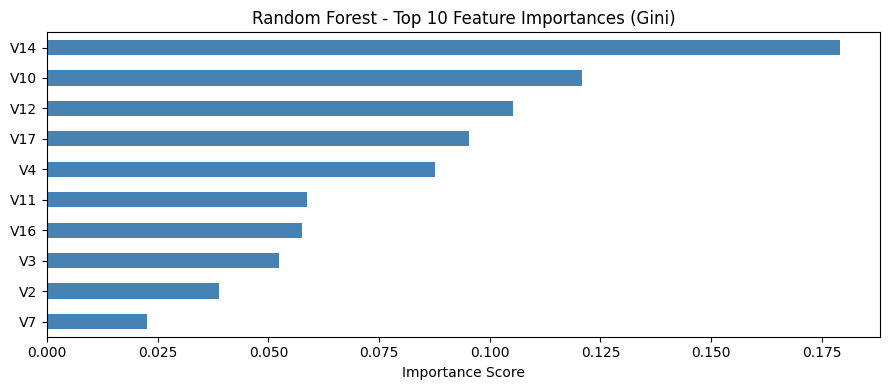

In [20]:

# ============================================================
# STEP 6 — METHOD 2: Random Forest
# ============================================================
print("\n" + "="*55)
print("METHOD 2: Random Forest")
print("="*55)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1              # use all CPU cores to speed things up
)
rf.fit(X_train, y_train)

rf_probs_val  = rf.predict_proba(X_val)[:, 1]
rf_probs_test = rf.predict_proba(X_test)[:, 1]
rf_thresh     = best_threshold(y_val, rf_probs_val)

print(f"Best threshold from val set: {rf_thresh:.3f}")
rf_results = evaluate('Random Forest', y_test, rf_probs_test, rf_thresh)
print(pd.DataFrame([rf_results]).to_string(index=False))
print(classification_report(
    y_test, (rf_probs_test >= rf_thresh).astype(int),
    target_names=['Legit','Fraud']))

# Feature importance from Random Forest (Gini)
# This answers Research Question 4 in our proposal
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top10 = feat_imp.nlargest(10)

plt.figure(figsize=(9, 4))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest - Top 10 Feature Importances (Gini)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()


In [21]:
print(f"\nTop 5 most important features: {list(top10.head().index)}")


Top 5 most important features: ['V14', 'V10', 'V12', 'V17', 'V4']


In [22]:

# ============================================================
# STEP 7 — METHOD 3: XGBoost
# ============================================================
print("\n" + "="*55)
print("METHOD 3: XGBoost")
print("="*55)

# scale_pos_weight is equivalent to our w1/w0 ratio (~578)
xgb = XGBClassifier(
    scale_pos_weight = n_legit / n_fraud,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

xgb_probs_val  = xgb.predict_proba(X_val)[:, 1]
xgb_probs_test = xgb.predict_proba(X_test)[:, 1]
xgb_thresh     = best_threshold(y_val, xgb_probs_val)

print(f"Best threshold from val set: {xgb_thresh:.3f}")
xgb_results = evaluate('XGBoost', y_test, xgb_probs_test, xgb_thresh)
print(pd.DataFrame([xgb_results]).to_string(index=False))
print(classification_report(
    y_test, (xgb_probs_test >= xgb_thresh).astype(int),
    target_names=['Legit','Fraud']))



METHOD 3: XGBoost
Best threshold from val set: 0.889
  Model  AUPRC  AUROC     F1  Precision  Recall
XGBoost 0.7643 0.9768 0.7846     0.9273    0.68
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.93      0.68      0.78        75

    accuracy                           1.00     56962
   macro avg       0.96      0.84      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
# ============================================================
# STEP 8 — METHOD 4: MLP (Deep Learning) with 5-Seed Evaluation
# ============================================================
print("\n" + "="*55)
print("METHOD 4: MLP (Deep Learning) — 5 Seeds")
print("="*55)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# This is the architecture from our proposal: 30 -> 64 -> 32 -> 1
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
            # No sigmoid here - BCEWithLogitsLoss handles it internally
        )

    def forward(self, x):
        return self.network(x)

# Convert to tensors for PyTorch
def to_tensors(X, y):
    return (torch.tensor(X.values, dtype=torch.float32),
            torch.tensor(y.values, dtype=torch.float32).unsqueeze(1))

Xt_train, yt_train = to_tensors(X_train, y_train)
Xt_val,   yt_val   = to_tensors(X_val,   y_val)
Xt_test,  yt_test  = to_tensors(X_test,  y_test)

# pos_weight captures our w1/w0 class imbalance ratio
# Loss = -[w1 * y * log(p) + w0 * (1-y) * log(1-p)]
pos_weight = torch.tensor([w1 / w0]).to(device)

seed_results = []
seed_probs   = []

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    model     = FraudMLP(input_dim=X_train.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loader = DataLoader(
        TensorDataset(Xt_train, yt_train),
        batch_size=256, shuffle=True
    )

    best_val_f1    = 0
    best_thresh    = 0.5
    best_state     = None
    patience_count = 0

    for epoch in range(50):
        # Training pass
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        # Check performance on validation set
        model.eval()
        with torch.no_grad():
            val_logits = model(Xt_val.to(device)).cpu().numpy().flatten()
            val_probs  = 1 / (1 + np.exp(-val_logits))  # sigmoid manually

        thresh = best_threshold(y_val, val_probs)
        val_f1 = f1_score(y_val, (val_probs >= thresh).astype(int))

        # Save best model and use early stopping
        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_thresh    = thresh
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= 5:
                print(f"  Seed {seed}: early stopping at epoch {epoch+1}")
                break

    # Load best checkpoint and evaluate on test set
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(Xt_test.to(device)).cpu().numpy().flatten()
        test_probs  = 1 / (1 + np.exp(-test_logits))

    res = evaluate(f'MLP (seed={seed})', y_test, test_probs, best_thresh)
    seed_results.append(res)
    seed_probs.append(test_probs)
    print(f"  Seed {seed}: AUPRC={res['AUPRC']:.4f} | F1={res['F1']:.4f} | Threshold={best_thresh:.3f}")

# Report mean and std across all 5 seeds
mlp_df = pd.DataFrame(seed_results)
print(f"\nMLP Results across {len(SEEDS)} seeds:")
for col in ['AUPRC','AUROC','F1','Precision','Recall']:
    print(f"  {col:10s}: {mlp_df[col].mean():.4f} ± {mlp_df[col].std():.4f}")

# Average probabilities across seeds for final plots
mlp_probs_avg = np.mean(seed_probs, axis=0)





METHOD 4: MLP (Deep Learning) — 5 Seeds
Running on: cuda
  Seed 42: early stopping at epoch 12
  Seed 42: AUPRC=0.8062 | F1=0.8000 | Threshold=0.998
  Seed 123: early stopping at epoch 13
  Seed 123: AUPRC=0.8099 | F1=0.8154 | Threshold=0.994
  Seed 256: early stopping at epoch 10
  Seed 256: AUPRC=0.8051 | F1=0.8095 | Threshold=0.998
  Seed 789: early stopping at epoch 9
  Seed 789: AUPRC=0.8117 | F1=0.8154 | Threshold=0.987
  Seed 1024: early stopping at epoch 9
  Seed 1024: AUPRC=0.8031 | F1=0.7939 | Threshold=0.997

MLP Results across 5 seeds:
  AUPRC     : 0.8072 ± 0.0035
  AUROC     : 0.9783 ± 0.0063
  F1        : 0.8068 ± 0.0096
  Precision : 0.9512 ± 0.0381
  Recall    : 0.7013 ± 0.0152


In [24]:

# ============================================================
# STEP 9 — ABLATION: MLP Depth
# ============================================================
print("\n" + "="*55)
print("ABLATION: MLP Depth (1 vs 2 vs 3 hidden layers)")
print("="*55)

#Testing whether adding more layers actually helps
# Hypothesis: 2 layers is enough for this dataset
depth_configs = {
    '1 Layer  (64)':        [64],
    '2 Layers (64, 32)':    [64, 32],
    '3 Layers (128, 64, 32)':[128, 64, 32],
}

def build_mlp(layers, input_dim):
    blocks, in_d = [], input_dim
    for out_d in layers:
        blocks += [nn.Linear(in_d, out_d), nn.BatchNorm1d(out_d),
                   nn.ReLU(), nn.Dropout(0.3)]
        in_d = out_d
    blocks.append(nn.Linear(in_d, 1))
    return nn.Sequential(*blocks)

depth_results = []
for config_name, layers in depth_configs.items():
    auprcs = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        m   = build_mlp(layers, X_train.shape[1]).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=1e-3)
        crt = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        dl  = DataLoader(TensorDataset(Xt_train, yt_train), batch_size=256, shuffle=True)

        best_f1, p_count = 0, 0
        for _ in range(50):
            m.train()
            for xb, yb in dl:
                opt.zero_grad()
                crt(m(xb.to(device)), yb.to(device)).backward()
                opt.step()
            m.eval()
            with torch.no_grad():
                vp = 1 / (1 + np.exp(-m(Xt_val.to(device)).cpu().numpy().flatten()))
            vf = f1_score(y_val, (vp >= 0.5).astype(int))
            if vf > best_f1: best_f1, p_count = vf, 0
            else:
                p_count += 1
                if p_count >= 5: break
        m.eval()
        with torch.no_grad():
            tp = 1 / (1 + np.exp(-m(Xt_test.to(device)).cpu().numpy().flatten()))
        auprcs.append(average_precision_score(y_test, tp))

    depth_results.append({
        'Config':     config_name,
        'AUPRC Mean': round(np.mean(auprcs), 4),
        'AUPRC Std':  round(np.std(auprcs), 4)
    })
    print(f"  {config_name}: {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")

print(pd.DataFrame(depth_results).to_string(index=False))



ABLATION: MLP Depth (1 vs 2 vs 3 hidden layers)
  1 Layer  (64): 0.7605 ± 0.0278
  2 Layers (64, 32): 0.7824 ± 0.0215
  3 Layers (128, 64, 32): 0.7844 ± 0.0194
                Config  AUPRC Mean  AUPRC Std
         1 Layer  (64)      0.7605     0.0278
     2 Layers (64, 32)      0.7824     0.0215
3 Layers (128, 64, 32)      0.7844     0.0194



ABLATION: Threshold Sensitivity
Best threshold for RF: 0.20 (F1=0.8321)


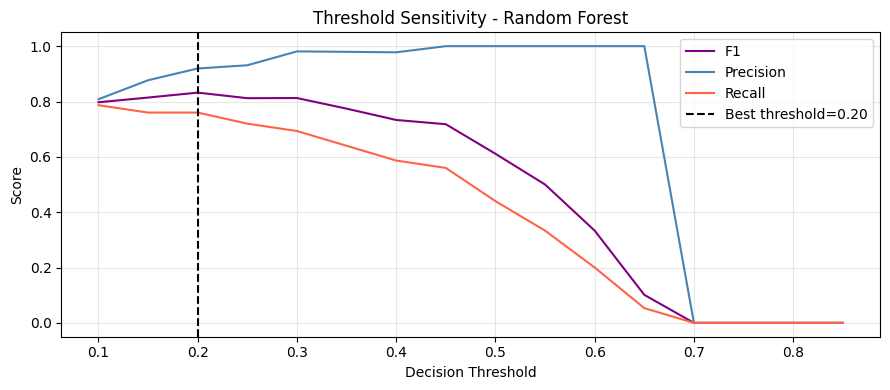

In [25]:
# ============================================================
# STEP 10 — ABLATION: Threshold Sensitivity
# ============================================================
print("\n" + "="*55)
print("ABLATION: Threshold Sensitivity")
print("="*55)

 # Showing how precision/recall trade off as we move the threshold
# The default 0.5 is almost never optimal for imbalanced data
thresholds  = np.arange(0.1, 0.9, 0.05)
t_f1s  = [f1_score(y_test, (rf_probs_test>=t).astype(int)) for t in thresholds]
t_prec = [precision_score(y_test, (rf_probs_test>=t).astype(int), zero_division=0) for t in thresholds]
t_rec  = [recall_score(y_test, (rf_probs_test>=t).astype(int)) for t in thresholds]

best_t = thresholds[np.argmax(t_f1s)]
print(f"Best threshold for RF: {best_t:.2f} (F1={max(t_f1s):.4f})")

plt.figure(figsize=(9, 4))
plt.plot(thresholds, t_f1s,  label='F1',       color='purple')
plt.plot(thresholds, t_prec, label='Precision', color='steelblue')
plt.plot(thresholds, t_rec,  label='Recall',    color='tomato')
plt.axvline(best_t, color='black', linestyle='--', label=f'Best threshold={best_t:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Sensitivity - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150)
plt.show()



FINAL: Comparison
              Model  AUPRC  AUROC     F1  Precision  Recall
Logistic Regression 0.7429 0.9819 0.7812     0.9434  0.6667
      Random Forest 0.8061 0.9380 0.8201     0.8906  0.7600
            XGBoost 0.7643 0.9768 0.7846     0.9273  0.6800
     MLP (mean±std) 0.8072 0.9783 0.8068     0.9512  0.7013


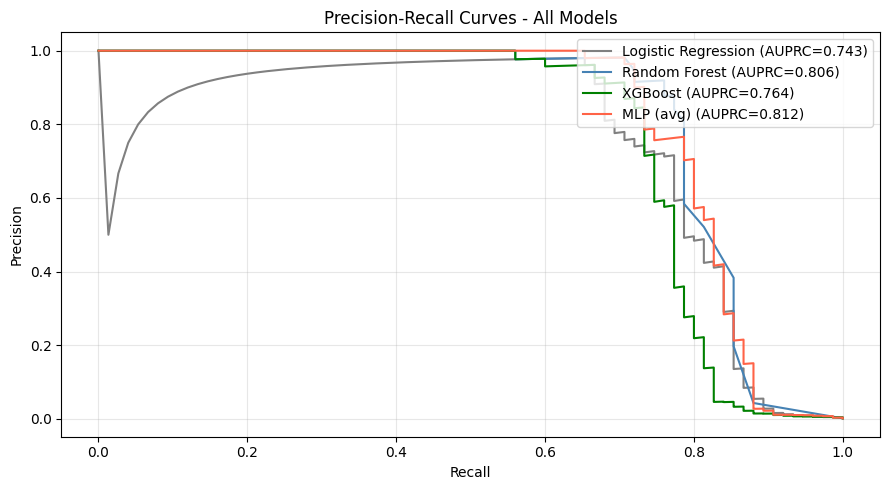

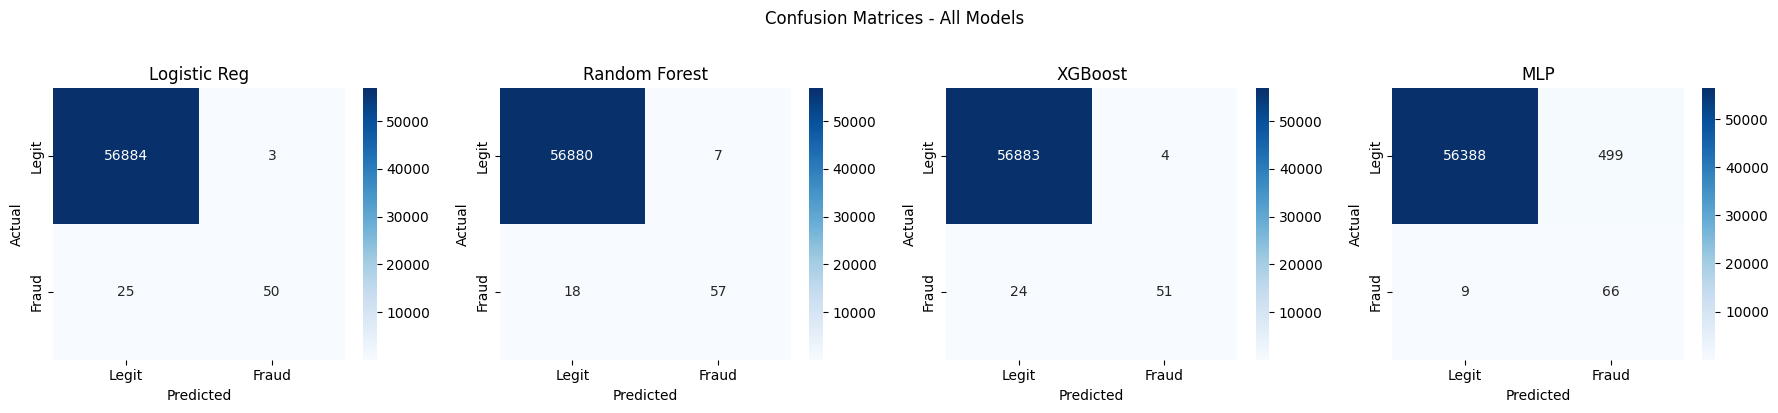

In [26]:
# ============================================================
# STEP 11 — FINAL COMPARISON TABLE
# ============================================================
print("\n" + "="*55)
print("FINAL: Comparison")
print("="*55)


all_results = [
    lr_results,
    rf_results,
    xgb_results,
    {
        'Model':     'MLP (mean±std)',
        'AUPRC':     round(mlp_df['AUPRC'].mean(), 4),
        'AUROC':     round(mlp_df['AUROC'].mean(), 4),
        'F1':        round(mlp_df['F1'].mean(), 4),
        'Precision': round(mlp_df['Precision'].mean(), 4),
        'Recall':    round(mlp_df['Recall'].mean(), 4),
    }
]
print(pd.DataFrame(all_results).to_string(index=False))

# Precision-Recall curves for all models
plt.figure(figsize=(9, 5))
for probs, name, color in [
    (lr_probs_test,   'Logistic Regression', 'gray'),
    (rf_probs_test,   'Random Forest',       'steelblue'),
    (xgb_probs_test,  'XGBoost',             'green'),
    (mlp_probs_avg,   'MLP (avg)',            'tomato'),
]:
    p, r, _ = precision_recall_curve(y_test, probs)
    auprc   = average_precision_score(y_test, probs)
    plt.plot(r, p, label=f'{name} (AUPRC={auprc:.3f})', color=color)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, probs, thresh, name in zip(
    axes,
    [lr_probs_test, rf_probs_test, xgb_probs_test, mlp_probs_avg],
    [lr_thresh, rf_thresh, xgb_thresh, 0.5],
    ['Logistic Reg', 'Random Forest', 'XGBoost', 'MLP']
):
    cm = confusion_matrix(y_test, (probs >= thresh).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

